# SFINCS Demo

In this demo, we will practice building and creating a SFINCS model for the region around Asbury Park, NJ during Hurricane Sandy.

In [2]:
# Imports
import os
import subprocess
from datetime import datetime
from pathlib import Path

from hydromt._utils import log
from hydromt_sfincs import SfincsModel, DATADIR, utils
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import hvplot.xarray 


## Build the Model

### 1. Initialize SfincsModel, set data library, and output folder

In [3]:
model_root = "../model"

log.initialize_logging()
log.set_log_level(log_level=30)  # Only errors and critical

# Add file handler to log to a file
log_file = Path(model_root) / "hydromt_sfincs.log"
logger = log._add_filehandler(log_file)

# Add data catalogs
data_libs = ["/home/zagreus/nj_sandy_sfincs/data/data_catalog.yml"]

# Create model
sf = SfincsModel(
    data_libs=data_libs, root=model_root, mode="w+", write_gis=True
)


2026-05-08 14:47:58,454 - hydromt.model.model - model - WARNING - No region component found in components.


### 2. Specify grid

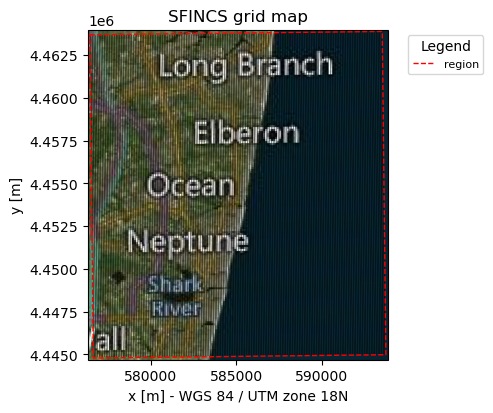

In [4]:
# Create grid from region
sf.grid.create_from_region(
    region={"geom": "/home/zagreus/nj_sandy_sfincs/data/region.geojson"},
    res=100,
    rotated=True,
    crs="utm",
)

# Show model grid outline
_ = sf.plot_basemap(
    variable="grid",
    plot_region=True,
    bmap="sat",
    zoomlevel=10,
    grid_kwargs={"linewidth": 0.3},
)


### 3. Add elevation

2026-05-08 14:48:03,074 - hydromt.hydromt_sfincs.components.grid.elevation - elevation - WARNING - Interpolate elevation at 1 cells


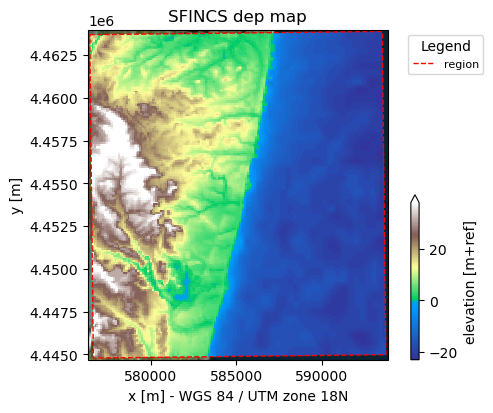

In [5]:
elevation_list = [
    {"elevation": "nj_10ft_dem", "zmin": 0.001},
    {"elevation": "gebco_nj"},
]

sf.elevation.create(elevation_list=elevation_list, buffer_cells=1)

# Plot the merged topobathy (colour limits set between -25 m and +10 m to show NJ shelf)
_ = sf.plot_basemap(
    variable="dep",
    plot_region=True,
    bmap="sat",
    zoomlevel=10,
)

### 4. Make mask of activate and inactive cells

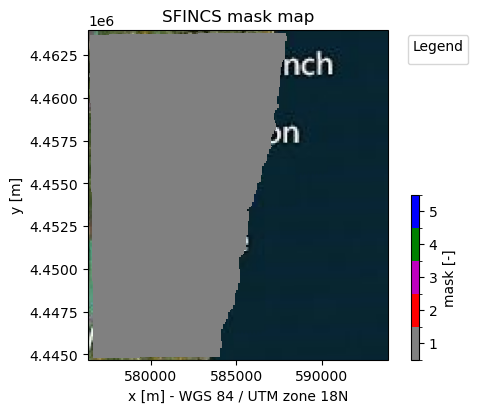

In [6]:
# All cells with elevation >= -10 m are considered active
# The NJ shelf is shallow, so -10 m captures it without going too far offshore
sf.mask.create_active(zmin=-10)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=True,
    bmap="sat",
    zoomlevel=10,
)

### 5. Update mask with water level boundary cells:

In [7]:
dep = sf.grid.data["dep"]
east_edge = dep.isel(x=-1)
print(east_edge.values)
print(f"min: {east_edge.values.min():.1f}  max: {east_edge.values.max():.1f}")

[-17. -17. -17. -17. -17. -17. -17. -18. -18. -18. -19. -19. -19. -19.
 -19. -19. -19. -19. -19. -19. -19. -19. -19. -19. -19. -20. -19. -19.
 -19. -19. -19. -19. -19. -19. -19. -19. -19. -20. -20. -20. -19. -19.
 -19. -19. -19. -19. -18. -18. -18. -18. -18. -19. -19. -19. -19. -19.
 -20. -20. -20. -21. -21. -21. -22. -22. -22. -22. -22. -22. -21. -20.
 -20. -19. -19. -19. -19. -19. -20. -20. -21. -22. -22. -22. -22. -22.
 -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21.
 -21. -21. -21. -21. -20. -20. -20. -20. -20. -20. -21. -21. -21. -21.
 -22. -22. -22. -22. -22. -22. -22. -22. -22. -22. -22. -21. -21. -21.
 -21. -20. -20. -20. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21.
 -21. -21. -21. -21. -21. -22. -22. -22. -22. -22. -22. -22. -22. -21.
 -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21.
 -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21. -21.
 -21. -21. -21. -21. -21. -21. -21.]
min: -22.0  max: -17.0


2026-05-08 14:48:04,224 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


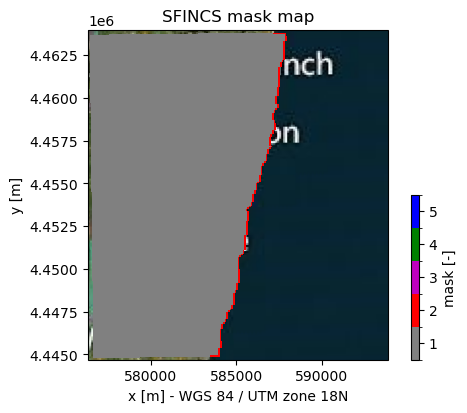

In [8]:
# Mark offshore edge cells (depth > 1 m) as water level boundary cells
sf.mask.create_boundary(
    btype="waterlevel",
    zmax=-1,
    reset_bounds=True,
)

_ = sf.plot_basemap(
    variable="mask",
    plot_region=False,
    plot_bounds=False,
    bmap="sat",
    zoomlevel=10,
)

### 6. Add observation points

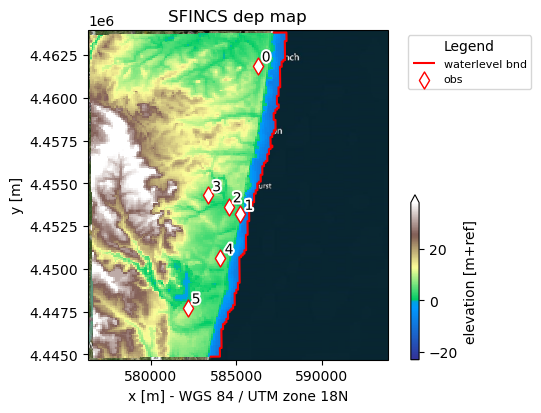

In [9]:
# sf.observation_points.create(locations="/home/zagreus/nj_sandy_sfincs/data/obs.geojson")
obs_gdf = gpd.read_file("../data/obs.geojson")
offshore = gpd.GeoDataFrame(
    {"name": ["offshore_test"]},
    geometry=[Point(-73.92, 40.20)],
    crs="EPSG:4326"
)
obs_all = gpd.GeoDataFrame(
    pd.concat([obs_gdf, offshore], ignore_index=True),
    crs="EPSG:4326"
)
sf.observation_points.create(locations=obs_all, merge=False)
# sf.write()

_ = sf.plot_basemap(
    variable="dep",
    plot_geoms=True,
    plot_bounds=True,
    bmap="sat",
    zoomlevel=12,
)


### 7. Add spatially varying roughness data

2026-05-08 14:49:35,111 - hydromt.gis.raster - raster - WARNING - The nodata value None is not in the reclass table.None will be used for the params.
2026-05-08 14:49:35,221 - hydromt.hydromt_sfincs.components.grid.roughness - roughness - WARNING - nan values in manning roughness array


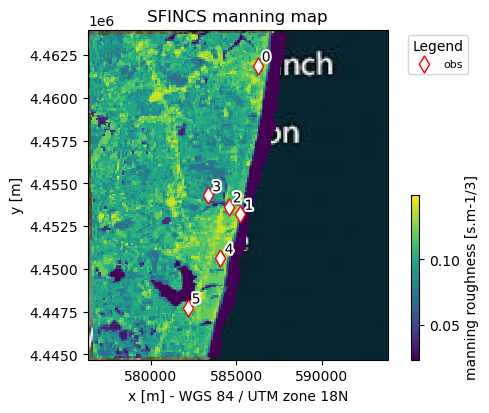

In [11]:
reclass_table = os.path.join(DATADIR, "lulc", "NLCD_SFBD_mapping.csv")

roughness_list = [{"lulc": "nlcd_2012", "reclass_table": reclass_table}]

sf.roughness.create(
    roughness_list=roughness_list,
    manning_land=0.04,
    manning_sea=0.02,
    rgh_lev_land=0,
)

_ = sf.plot_basemap(variable="manning", plot_bounds=False, bmap="sat", zoomlevel=10)

### 8. Make subgrid derived tables:

In [12]:
elevation_list = [
    {"elevation": "nj_10ft_dem", "zmin": 0.001},
    {"elevation": "gebco_nj"},
]
roughness_list = [{"lulc": "nlcd_2012", "reclass_table": reclass_table}]

sf.subgrid.create(
    elevation_list=elevation_list,
    roughness_list=roughness_list,
    nr_subgrid_pixels=8,
    write_dep_tif=True,
    write_man_tif=True,
)


2026-05-08 14:49:37,006 - hydromt.data_catalog.data_catalog - data_catalog - WARNING - overwriting data source 'NLCD_SFBD_mapping.csv' with provider user and version _UNSPECIFIED_.
2026-05-08 14:49:37,010 - hydromt.gis.raster - raster - WARNING - The nodata value None is not in the reclass table.None will be used for the params.
2026-05-08 14:49:40,914 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - WARNING - Fill manning roughness data at 2555 subgrid pixels with default values


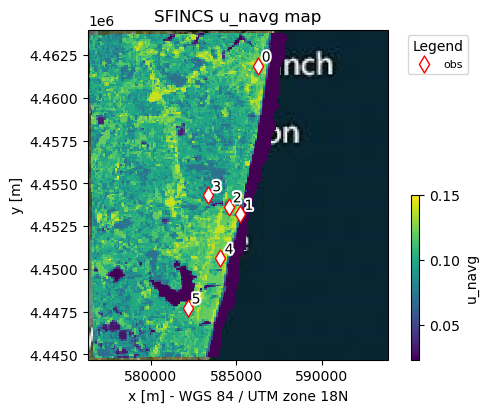

In [13]:
# Plot one of the 2D subgrid variables — u_navg is the representative depth for momentum fluxes
_ = sf.plot_basemap(
    variable=sf.subgrid.data["u_navg"],
    plot_bounds=False,
    bmap="sat",
    zoomlevel=10,
)

### 9. Add water level time-series as forcing

In [14]:
# Set the simulation period to cover Hurricane Sandy's landfall
sf.config.update(
    {
        "tref": datetime(2012, 10, 28),
        "tstart": datetime(2012, 10, 29),
        "tstop": datetime(2012, 10, 31),
        "dtmapout": 3600.0,   # hourly map snapshots -> creates sfincs_map.nc
        "dtmaxout": 86400.0,  # write max values once per day
        "dthisout": 600.0,    # observation point output every 10 min
    }
)

# Apply GTSM-ERA5-E tidal/surge time series to boundary cells
# buffer=50000 m searches for GTSM stations within 50 km of boundary cells
sf.water_level.create(
    geodataset="gtsm_era5_nj",
    buffer=50000,
)

### 10. Save out model

In [15]:
# write all model files to disk
sf.write()

## Running the model

### 1. Run via Docker

In [16]:
log_path = Path(model_root) / "sfincs_log.txt"
model_abs = Path(model_root).resolve()

# Remove stale output files before running — Docker writes them as root, and SFINCS
# gets "NetCDF: Not a valid ID" errors if it tries to overwrite root-owned files.
subprocess.run(
    [
        "docker", "run", "--rm",
        "-v", f"{model_abs}:/data",
        "--entrypoint", "/bin/sh",
        "deltares/sfincs-cpu:latest",
        "-c", "rm -f /data/sfincs_map.nc /data/sfincs_his.nc",
    ],
    capture_output=True,
)

print(f"Running SFINCS via Docker on {model_abs} ...")
with open(log_path, "w") as log_file:
    result = subprocess.run(
        [
            "docker", "run", "--rm",
            "-v", f"{model_abs}:/data",
            "deltares/sfincs-cpu:latest",
        ],
        stdout=log_file,
        stderr=subprocess.STDOUT,
    )
print(f"Done (return code {result.returncode})")


Running SFINCS via Docker on /home/zagreus/nj_sandy_sfincs/model ...
Done (return code 0)


In [17]:
# Read the SFINCS log file
log_path = Path(model_root) / "sfincs_log.txt"
if log_path.exists():
    print(log_path.read_text())
else:
    print("No log file found — SFINCS has not run yet.")


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@.@@@.@....@@.....::.
    .:::~@@.:...:.@@...@@.:.:.@@~::::.
     .::~@@@@@@@@@@.....@@@@@@@@@~::.
       ..:~~~~~~~:.......:~~~~~~~:.

In [18]:
# Check that output files were created
map_nc = Path(model_root) / "sfincs_map.nc"
his_nc = Path(model_root) / "sfincs_his.nc"

print(f"sfincs_map.nc exists: {map_nc.exists()}")
print(f"sfincs_his.nc exists: {his_nc.exists()}")

sfincs_map.nc exists: True
sfincs_his.nc exists: True


## Visualization

### 1. Read Model Results

In [19]:
mod = SfincsModel(model_root, data_libs=data_libs, mode="r")
mod.output.read()

print("Output variables available:")
list(mod.output.data.keys())

2026-05-08 14:49:58,178 - hydromt.model.model - model - WARNING - No region component found in components.
2026-05-08 14:49:58,245 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: inp
2026-05-08 14:49:58,246 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: msk
2026-05-08 14:49:58,246 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zb
2026-05-08 14:49:58,247 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zs
2026-05-08 14:49:58,248 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zsmax
2026-05-08 14:49:58,248 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: total_runtime
2026-05-08 14:49:58,249 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: average_dt
2026-05-08 14:49:58,249 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: 

['inp',
 'msk',
 'zb',
 'zs',
 'zsmax',
 'total_runtime',
 'average_dt',
 'status',
 'point_zb',
 'point_zs']

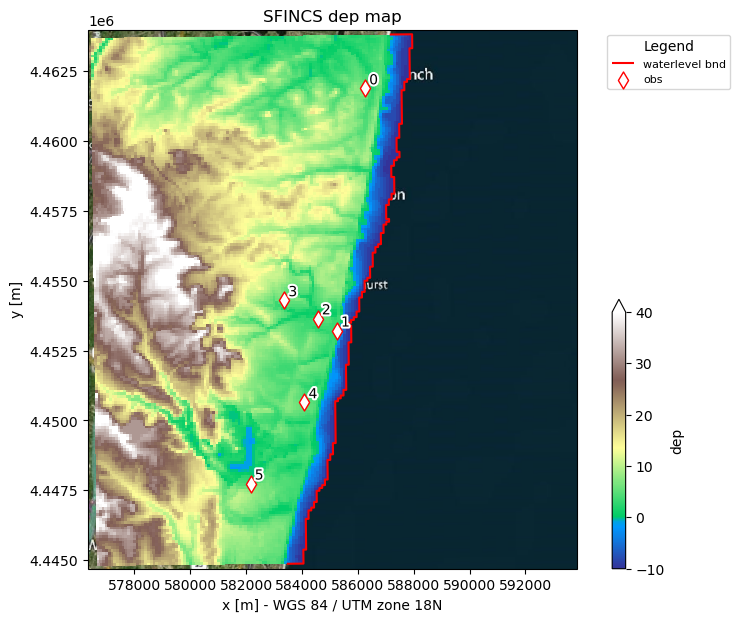

In [20]:
# Plot the model layout — grid, boundary cells, and observation points
fig, ax = mod.plot_basemap(fn_out=None, bmap="sat", figsize=(9, 7), geom_names=["obs"])

### 2. Downscale Flood Map

In [21]:
# Load the 25 m subgrid DEM (written during model build with write_dep_tif=True)
depfile = Path(model_root) / "subgrid" / "dep_subgrid.tif"
da_dep = rioxarray.open_rasterio(depfile, masked=True).squeeze("band", drop=True)
print(f"Subgrid DEM shape: {da_dep.shape}, resolution: {da_dep.rio.resolution()}")

ds_map = xr.open_dataset(model_abs / "sfincs_map.nc")
ds_his = xr.open_dataset(model_abs / "sfincs_his.nc")

sf_r = SfincsModel(str(model_abs), mode="r")
sf_r.output.read()
da_zsmax = sf_r.output.data["zsmax"].max(dim="timemax")

depfile = str(model_abs / "subgrid" / "dep_subgrid.tif")
da_dep = sf_r.data_catalog.get_rasterdataset(depfile)

da_hmax = utils.downscale_floodmap(zsmax=da_zsmax, dep=da_dep, hmin=0.05)

da_hmax = da_hmax.where(da_dep > -0.5)  # remove deep ocean cells, keep beach face


Subgrid DEM shape: (1512, 1368), resolution: (12.49920795547668, 12.499207955476717)
2026-05-08 14:50:02,306 - hydromt.model.model - model - WARNING - No region component found in components.
2026-05-08 14:50:02,366 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: inp
2026-05-08 14:50:02,366 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: msk
2026-05-08 14:50:02,367 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zb
2026-05-08 14:50:02,368 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zs
2026-05-08 14:50:02,368 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: zsmax
2026-05-08 14:50:02,369 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: total_runtime
2026-05-08 14:50:02,369 - hydromt.hydromt_sfincs.components.output - output - WARNING - Replacing result: average_dt
2026-05-08 14:50:02,3

### 3. Mask permanent bodies of water


In [22]:
# nlcd = rioxarray.open_rasterio(
#     model_abs.parent / "data/roughness/nlcd_2012.tif", masked=True
# ).squeeze("band", drop=True)

# # Reproject NLCD to match the downscaled flood map
# nlcd_reproj = nlcd.raster.reproject_like(da_hmax, method="nearest")

# # Mask out permanent water (class 11) and cells below hmin
# da_hmax = da_hmax.where(nlcd_reproj != 11)

Text(0.5, 1.0, 'SFINCS maximum water depth')

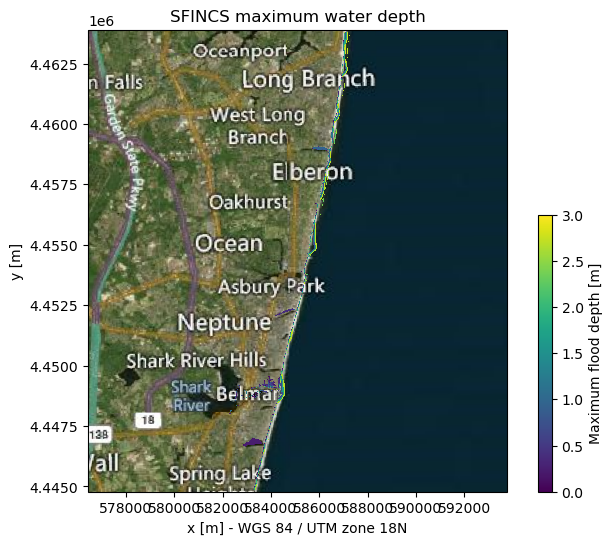

In [23]:
fig, ax = mod.plot_basemap(
    fn_out=None,
    figsize=(8, 6),
    variable=da_hmax,
    plot_bounds=False,
    plot_geoms=False,
    bmap="sat",
    zoomlevel=11,
    vmin=0,
    vmax=3.0,
    cbar_kwargs={"shrink": 0.6, "anchor": (0, 0)},
)
ax.set_title(f"SFINCS maximum water depth")

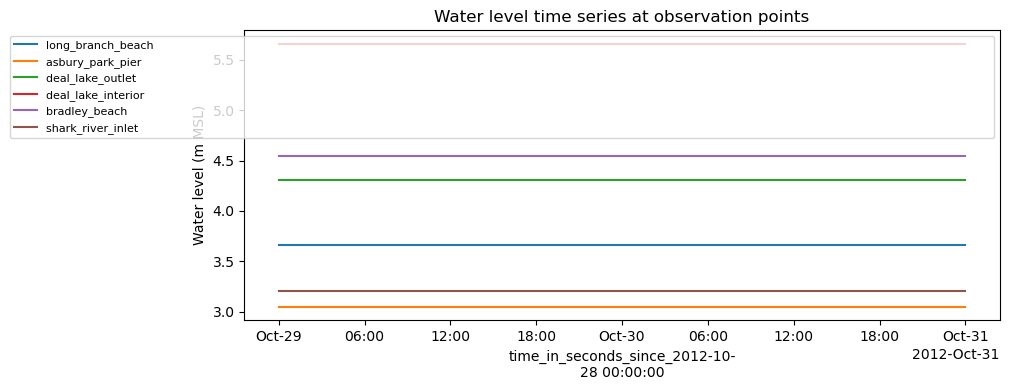

In [22]:
# ── Time series at observation points ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for i, name in enumerate(ds_his["station_name"].values):
    label = name.decode() if isinstance(name, bytes) else name
    ds_his["point_zs"].isel(stations=i).plot(ax=ax, label=label)
ax.set_ylabel("Water level (m MSL)")
ax.set_title("Water level time series at observation points")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

In [23]:
print(da_dep.min().values, da_dep.max().values)


-12.0 61.0587


In [25]:
import hvplot.pandas

flood_wgs84 = da_hmax.where(da_hmax > 0.05).rio.reproject(
    "EPSG:4326", nodata=float("nan")
)

flood_map = flood_wgs84.hvplot.image(
    x="x", y="y",
    cmap="viridis",
    clim=(0, 3),
    geo=True,
    tiles="EsriImagery",
    alpha=0.75,
    width=900, height=700,
    title="Max flood depth — Sandy baseline (no wind)",
    clabel="Flood depth [m]",
)

obs_layer = obs_all.hvplot.points(
    geo=True, color="red", size=60,
    hover_cols=["name"],
)

flood_map * obs_layer

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Image.I  :Image   [x,y]   (Maximum flood depth)
   .Points.I :Points   [Longitude,Latitude]   (name)